In [1]:
import cdflib
import numpy as np
import matplotlib.pyplot as plt

Input data

In [2]:
droot = '/Users/demajr1/files/imap_ultra/SDC/imap_data/imap/ultra/'
l1aRoot = droot+'l1a/2025/10/'
l1bRoot = droot+'l1b/2025/10/'
de = cdflib.CDF(l1bRoot+'imap_ultra_l1b_90sensor-de_20251019-repoint00022_v003.cdf')
xspin = cdflib.CDF(l1bRoot+'imap_ultra_l1b_90sensor-extendedspin_20251019-repoint00022_v004.cdf')
good = cdflib.CDF(l1bRoot+'imap_ultra_l1b_90sensor-goodtimes_20251019-repoint00022_v004.cdf')
bad = cdflib.CDF(l1bRoot+'imap_ultra_l1b_90sensor-badtimes_20251019-repoint00022_v002.cdf')

## Extended Spin, Good Times, Bad Times
It looks like the extended spin table, the good times and the bad times have the same structure. We also have

In [3]:
print(f"Extended spin tabel length {len(xspin['spin_number'])}")
print(f"good times length {len(good['spin_number'])}")
print(f"bad times length {len(bad['spin_number'])}")

print(f"Bad spins are {bad['spin_number']}")
print(f"Good spin range is  {np.min(good['spin_number'])}-{np.max(good['spin_number'])}")

Extended spin tabel length 4120
good times length 4118
bad times length 2
Bad spins are [140309 146035]
Good spin range is  140310-146034


So only bad times are the first and last spins of the pointing (presumably partial spins). 

## Total duration of the pointing
Check out total duration of the good times

In [4]:
delt = np.max(good['spin_start_time']) - np.min(good['spin_start_time'])+good['spin_period'][-1]
day_secs = 86400
print(f"good times duration is {delt}s ({day_secs-delt} less than a day)")

good times duration is 86387.13089001738s (12.86910998262465 less than a day)


This seems to imply that this pointing was almost a full day long with only 13 seconds for repointing. This needs to be checked. However, looking at the spin number vs time, we see


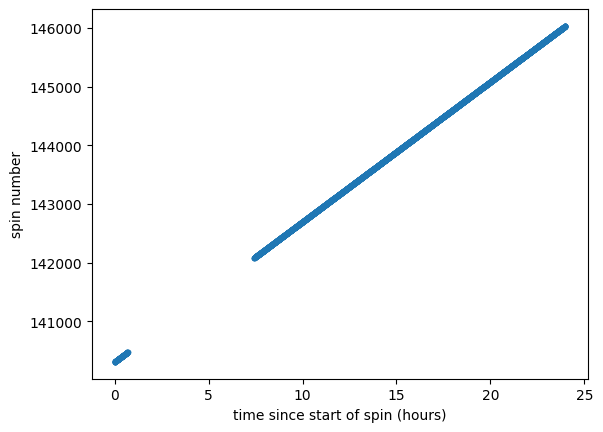

In [5]:
plt.plot((good['spin_start_time']-good['spin_start_time'][0])/3600,good['spin_number'],'.')
plt.xlabel('time since start of spin (hours)')
plt.ylabel('spin number')
plt.show()

looking at this gap in detail:

In [6]:
gap = np.max((good['spin_start_time'][1:]-good['spin_start_time'][0:-1])/3600)
print(f"time/spin gap is {gap}")
print(f"Total duration of good times: {np.sum((good['spin_period']))/3600} hrs")

time/spin gap is 6.7369233030577504
Total duration of good times: 17.263684312777777 hrs


Is this where the repoint shows up? If so, shouldn't the pointing start adter the gap? 

## Spin period/Rate
Checking period and rate consistency

In [7]:
rate_err = np.max(np.abs(good['spin_period'] - 60/good['spin_rate']))
print(f"maximum differences between spin period and rate calculation is {rate_err}s")

maximum differences between spin period and rate calculation is 0.0s


So rate calculation is consistent.

The spin periods (good times) are

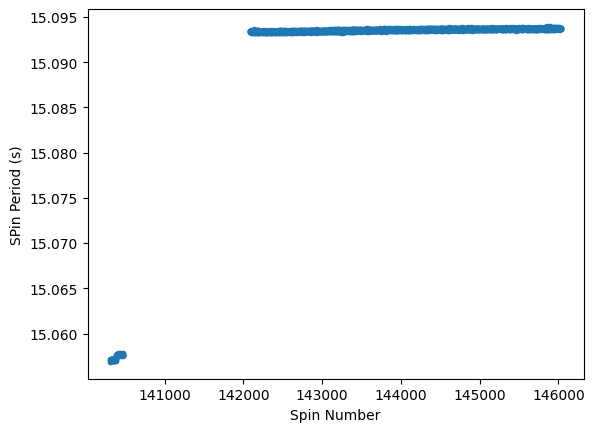

In [8]:
plt.plot(good['spin_number'], good['spin_period'],'.')
plt.xlabel("Spin Number")
plt.ylabel("SPin Period (s)")
plt.show()

So after the gap, the spin period is very consistent.

## Quality flags
Looking at the quality flags for the good times



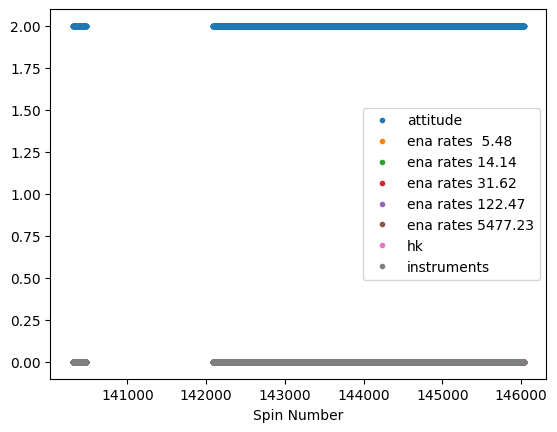

In [9]:
plt.plot(good['spin_number'],good['quality_attitude'],'.',label='attitude')
for ic in range(5):
    plt.plot(good['spin_number'],good['quality_ena_rates'][ic],'.',label=f"ena rates {good['energy_bin_geometric_mean'][ic]:5.2f}")
plt.plot(good['spin_number'],good['quality_hk'],'.',label='hk')
plt.plot(good['spin_number'],good['quality_instruments'],'.',label='instruments')
plt.legend()
plt.xlabel('Spin Number')
plt.show()

Basically all flags are zero except the attitude flag, which is 2.

## ENA rates
Checking ENA rates

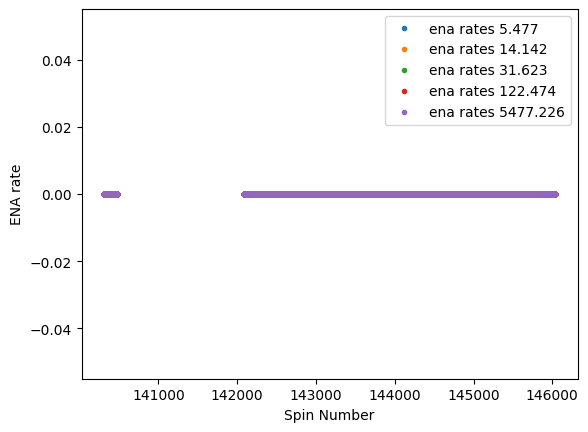

In [10]:
for ic in range(5):
    plt.plot(good['spin_number'],good['ena_rates'][ic],'.',label=f"ena rates {good['energy_bin_geometric_mean'][ic]:5.3f}")
plt.legend()
plt.xlabel('Spin Number')
plt.ylabel('ENA rate')
plt.show()


ENA rates are not being calculated

## Singles Rates
Turning to singles rates,

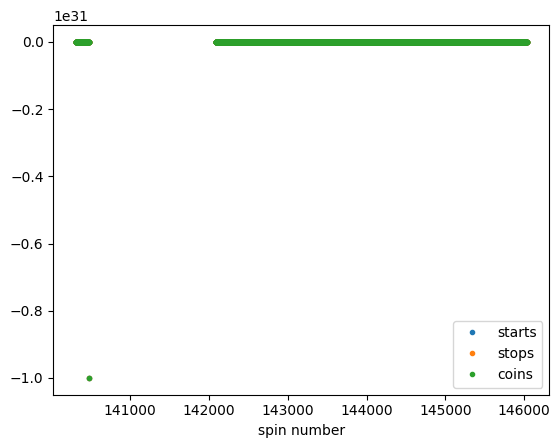

In [11]:
plt.plot(good['spin_number'],good['start_pulses_per_spin'],'.',label='starts')
plt.plot(good['spin_number'],good['stop_pulses_per_spin'],'.',label='stops')
plt.plot(good['spin_number'],good['coin_pulses_per_spin'],'.',label='coins')
plt.legend()
plt.xlabel('spin number')
plt.show()


So there is a fill value at the beginning of the gap. This should trip some sort of quality flag.
getting rid of this:

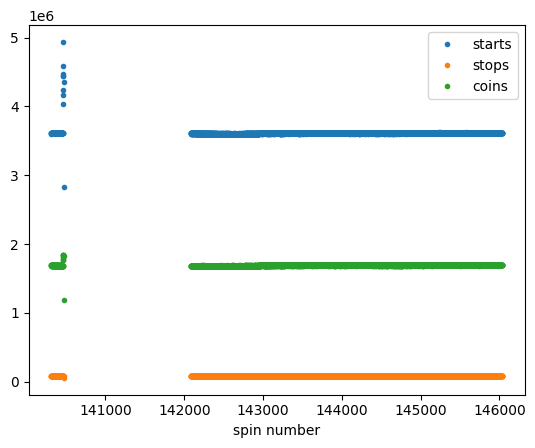

In [12]:
ii=np.nonzero(good['start_pulses_per_spin'] > 0)[0]
plt.plot(good['spin_number'][ii],good['start_pulses_per_spin'][ii],'.',label='starts')
plt.plot(good['spin_number'][ii],good['stop_pulses_per_spin'][ii],'.',label='stops')
plt.plot(good['spin_number'][ii],good['coin_pulses_per_spin'][ii],'.',label='coins')
plt.legend()
plt.xlabel('spin number')
plt.show()


Again - it looks like something is wierd just before the beginning of the gap that should probably be tripping a quality flag. Plotting these separately so the scales make sense:

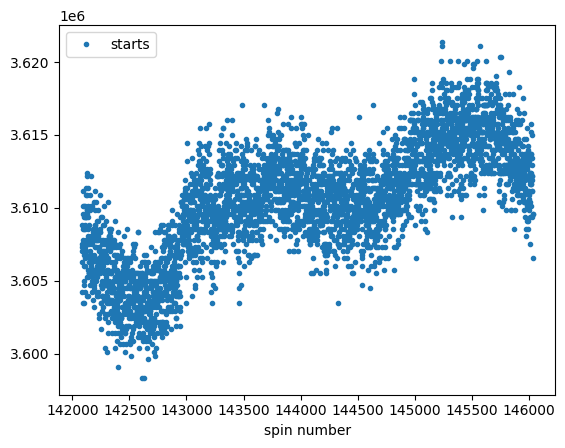

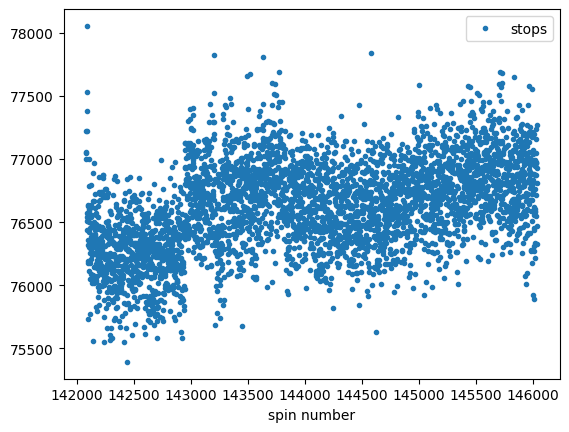

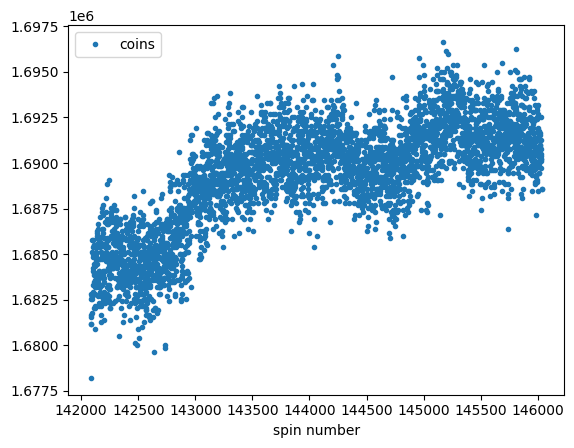

In [13]:
ii=np.nonzero(good['spin_number'] > 141500)[0]
plt.plot(good['spin_number'][ii],good['start_pulses_per_spin'][ii],'.',label='starts')
plt.legend()
plt.xlabel('spin number')
plt.show()
plt.plot(good['spin_number'][ii],good['stop_pulses_per_spin'][ii],'.',label='stops')
plt.legend()
plt.xlabel('spin number')
plt.show()
plt.plot(good['spin_number'][ii],good['coin_pulses_per_spin'][ii],'.',label='coins')
plt.legend()
plt.xlabel('spin number')
plt.show()

